In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential,utils
from tensorflow.keras.layers import Dense, Flatten,Conv2D, MaxPooling2D
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout, BatchNormalization

In [23]:
import os
print(os.listdir())

['.config', 'Dataset', 'chest-xray-pneumonia.zip', 'sample_data']


In [24]:
!pip install kaggle

In [25]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [26]:
import zipfile

with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("Dataset")

In [27]:
import os
print(os.listdir("Dataset"))

['chest_xray']


In [28]:
train_path = "Dataset/chest_xray/train"
val_path  = "Dataset/chest_xray/val"
test_path  = "Dataset/chest_xray/test"

In [29]:
# Dataset loading
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [30]:
# Normalization of pixels  for fast training and stable model
normalization_layer= tf.keras.layers.Rescaling(1./255)

def normalize(x, y):
    x = normalization_layer(x)
    return x, y

train_ds= train_ds.map(normalize) 
val_ds= val_ds.map(normalize) 
test_ds= test_ds.map(normalize) 

In [31]:
# data augumentation 
# model learn the traning data and that cause overfiting and bad performance on unseen data.
# by data augumentation we can create new data from exsisting data by getting different version of same images by flip rotate or zooming 
#model generalize better and perform better on unseen data

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# applying on traning dataset
def augment(x, y):
    x = data_augmentation(x)
    return x, y
train_ds = train_ds.map(augment)    

In [32]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [33]:
""" raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    seed=123,
    batch_size=32,
    shuffle=True
)

y_train = np.concatenate([y.numpy() for x, y in raw_train_ds], axis=0) """

' raw_train_ds = tf.keras.utils.image_dataset_from_directory(\n    train_path,\n    image_size=(224,224),\n    seed=123,\n    batch_size=32,\n    shuffle=True\n)\n\ny_train = np.concatenate([y.numpy() for x, y in raw_train_ds], axis=0) '

In [34]:
""" from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))
print(class_weights) """

" from sklearn.utils.class_weight import compute_class_weight\n\nclasses = np.unique(y_train)\n\nclass_weights = compute_class_weight(\n    class_weight='balanced',\n    classes=classes,\n    y=y_train\n)\n\nclass_weights = dict(zip(classes, class_weights))\nprint(class_weights) "

In [35]:
from tensorflow.keras.layers import GlobalAveragePooling2D,Activation
from tensorflow.keras import regularizers

In [36]:
# model Building 

model = Sequential()

model.add(Conv2D(32, (3, 3),input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3),input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))   
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3),input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))   
model.add(MaxPooling2D(2, 2))

model.add(GlobalAveragePooling2D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,513 (408.25 KB)

 Trainable params: 104,065 (406.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [38]:
from tensorflow.keras.optimizers import Adam

In [39]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])

In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [41]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
from pathlib import Path
from tensorflow.keras.models import load_model

MODEL_PATH = Path("pneumonia_predictor_model.keras")
TRAIN_FROM_SCRATCH = False  # Keep False to avoid retraining

if TRAIN_FROM_SCRATCH:
    history = model.fit(
        train_ds,
        epochs=20,
        validation_data=val_ds,
        callbacks=[early_stop],
    )
    model.save(MODEL_PATH)
    print(f"Training complete. Model saved to: {MODEL_PATH.resolve()}")
else:
    candidate_models = [
        MODEL_PATH,
        Path("pneumonia_predictor_model.h5"),
    ]
    selected_model = next((p for p in candidate_models if p.exists()), None)

    if selected_model is None:
        raise FileNotFoundError(
            "No saved model found. Place `pneumonia_predictor_model.keras` or "
            "`pneumonia_predictor_model.h5` in the project folder."
        )

    model = load_model(selected_model)
    history = None
    print(f"Loaded trained model from: {selected_model.resolve()}")

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 607ms/step - accuracy: 0.6638 - loss: 0.6110 - val_accuracy: 0.7766 - val_loss: 0.5362
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8047 - loss: 0.4202 - val_accuracy: 0.7766 - val_loss: 0.6923
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8486 - loss: 0.3542 - val_accuracy: 0.7766 - val_loss: 0.8286


In [43]:
# model evaluation
model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.6250 - loss: 0.6982


[0.6981804370880127, 0.625]

In [44]:
#predictions 
for image,lables in test_ds.take(1):
    preds=model.predict(image)
    print("Predictions:",preds[:10])
    print("Actual labels:",lables[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
Predictions: [[0.74381447]
 [0.732371  ]
 [0.7434794 ]
 [0.7394037 ]
 [0.7393848 ]
 [0.7406374 ]
 [0.7405555 ]
 [0.74092567]
 [0.7386705 ]
 [0.7521339 ]]
Actual labels: tf.Tensor([0 1 1 1 1 1 1 1 0 0], shape=(10,), dtype=int32)


In [45]:
#convert into 0/1 
preds=(preds>0.5).astype(int)
print("Predictions after thresholding:",preds[:10])

Predictions after thresholding: [[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [46]:
#confussion matrix
from sklearn.metrics import confusion_matrix, classification_report

In [47]:
true_labels = []
pred_labels = []
for images, labels in test_ds:
    y_pred = model.predict(images,verbose=0)
    y_pred = (y_pred > 0.5).astype(int)
    
    true_labels.extend(labels.numpy())
    pred_labels.extend(y_pred.flatten())
    
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[  0 234]
 [  0 390]]


In [48]:
#classification report
print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


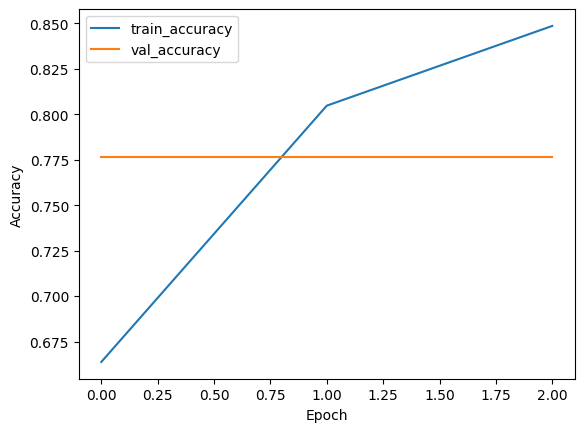

In [ ]:
# accuracy curve (available only when training is run in this notebook)
if history is not None:
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
else:
    print("Skipped accuracy plot because model was loaded (no in-notebook training history).")

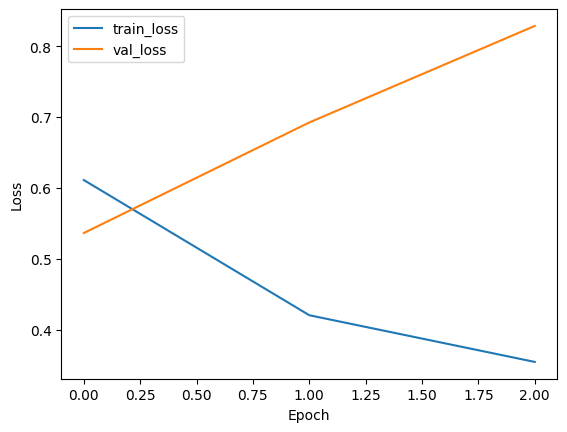

In [ ]:
# loss curve (available only when training is run in this notebook)
if history is not None:
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else:
    print("Skipped loss plot because model was loaded (no in-notebook training history).")

In [ ]:
# Optional: save/export current model
EXPORT_MODEL = False
if EXPORT_MODEL:
    model.save("pneumonia_predictor_model.keras")
    print("Model exported to pneumonia_predictor_model.keras")
else:
    print("Export skipped.")